In [0]:
# ============================================================
# C1 — IMPORTS
# ============================================================
# PySpark (chargement données uniquement)
from pyspark.sql import functions as F
from pyspark.sql.types import *
# IMPORTS MLFLOW
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient
# Scikit-learn — modeling
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Python standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings("ignore")

# Visualisation (Databricks compatible)
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print(" C1 — Imports chargés avec succès")


 C1 — Imports chargés avec succès


In [0]:
# ============================================================
# C2 — CHARGEMENT DES DONNÉES
# ============================================================

print("\n" + "=" * 60)
print("CHARGEMENT DES DONNÉES (DATABRICKS)")
print("=" * 60)

# Chargement table Delta
df_spark = spark.table("workspace.default.hospital_readmissions_modeling")

print(f"\n Données chargées depuis Delta Table")
print(f"  - Lignes : {df_spark.count():,}")
print(f"  - Colonnes : {len(df_spark.columns)}")

# Conversion contrôlée vers Pandas
print("\n Conversion Spark → Pandas (modélisation sklearn)...")
df = df_spark.toPandas()

print(f" Conversion terminée : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

print("\n Aperçu des données :")
display(df.head())

print("\n Types de données :")
display(df.dtypes)



CHARGEMENT DES DONNÉES (DATABRICKS)

 Données chargées depuis Delta Table
  - Lignes : 69,750
  - Colonnes : 9

 Conversion Spark → Pandas (modélisation sklearn)...
 Conversion terminée : 69,750 lignes × 9 colonnes

 Aperçu des données :


readmission_30j,patient_id,duree_sejour_category,charlson_category,medicaments_category,maladie_renale,admission_urgence,depression,gravite_category
false,PAT_000000,Très court,Moyen,Moyen,false,false,false,Sévère
true,PAT_000001,Très court,Faible,Moyen,false,true,true,Modérée
false,PAT_000002,Très court,Faible,Moyen,false,true,false,Sévère
false,PAT_000003,Long,Faible,Faible,false,false,false,Légère
true,PAT_000004,Moyen,Faible,Faible,false,true,false,Sévère



 Types de données :


readmission_30j            bool
patient_id               object
duree_sejour_category    object
charlson_category        object
medicaments_category     object
maladie_renale             bool
admission_urgence          bool
depression                 bool
gravite_category         object
dtype: object


ANALYSE VARIABLE CIBLE : RÉADMISSION

 STATISTIQUES GLOBALES :
  - Total patients        : 69,750
  - Réadmissions (1)      : 17,294
  - Non-réadmissions (0)  : 52,456
  - Taux de réadmission   : 24.79%
  - Ratio Non/Réadm       : 3.03


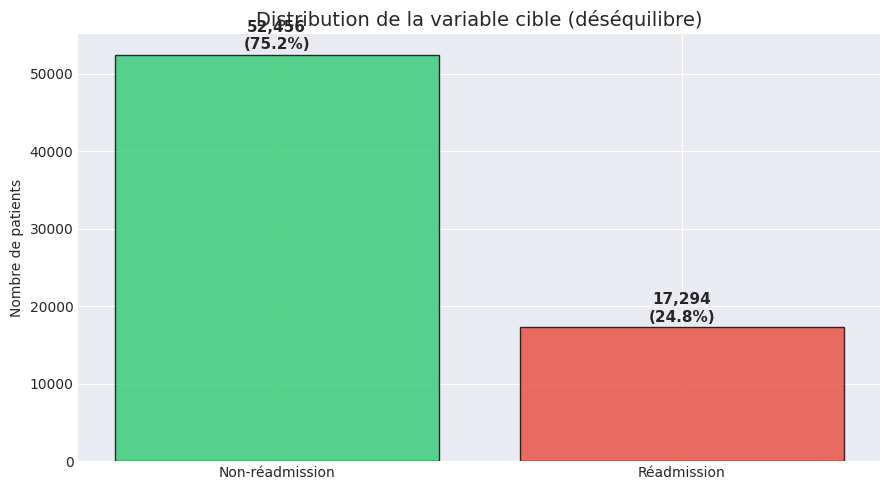


 DÉSÉQUILIBRE CONFIRMÉ — Traitement spécifique requis (Recall prioritaire)


In [0]:
# ============================================================
# C3 — ANALYSE DE LA VARIABLE CIBLE
# ============================================================

print("\n" + "=" * 60)
print("ANALYSE VARIABLE CIBLE : RÉADMISSION")
print("=" * 60)

target_col = "readmission_30j"

# Distribution brute
target_counts = df[target_col].value_counts().sort_index()

total = len(df)
positives = df[target_col].sum()
negatives = total - positives
taux_readmission = positives / total * 100

print(f"\n STATISTIQUES GLOBALES :")
print(f"  - Total patients        : {total:,}")
print(f"  - Réadmissions (1)      : {positives:,}")
print(f"  - Non-réadmissions (0)  : {negatives:,}")
print(f"  - Taux de réadmission   : {taux_readmission:.2f}%")
print(f"  - Ratio Non/Réadm       : {negatives / positives:.2f}")

# Visualisation
plt.figure(figsize=(9, 5))
plt.bar(
    ["Non-réadmission", "Réadmission"],
    [negatives, positives],
    color=["#2ecc71", "#e74c3c"],
    edgecolor="black",
    alpha=0.8
)

for i, v in enumerate([negatives, positives]):
    plt.text(i, v + total*0.01, f"{v:,}\n({v/total*100:.1f}%)",
             ha="center", fontsize=11, fontweight="bold")

plt.title("Distribution de la variable cible (déséquilibre)", fontsize=14)
plt.ylabel("Nombre de patients")
plt.tight_layout()
plt.show()

print("\n DÉSÉQUILIBRE CONFIRMÉ — Traitement spécifique requis (Recall prioritaire)")


In [0]:
# ============================================================
# C4 — PRÉPARATION DES FEATURES
# ============================================================

print("\n" + "=" * 60)
print("PRÉPARATION DES FEATURES")
print("=" * 60)

id_col = "patient_id"
target_col = "readmission_30j"

# Features = toutes sauf ID et cible
feature_cols = [c for c in df.columns if c not in [id_col, target_col]]

X = df[feature_cols]
y = df[target_col].astype(int)

# Séparation types
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print(f"\n FEATURES IDENTIFIÉES :")
print(f"  - Catégorielles : {len(categorical_cols)}")
print(f"    {categorical_cols}")
print(f"  - Numériques    : {len(numerical_cols)}")
print(f"    {numerical_cols}")

print("\n Préparation terminée")



PRÉPARATION DES FEATURES

 FEATURES IDENTIFIÉES :
  - Catégorielles : 4
    ['duree_sejour_category', 'charlson_category', 'medicaments_category', 'gravite_category']
  - Numériques    : 3
    ['maladie_renale', 'admission_urgence', 'depression']

 Préparation terminée


In [0]:
# ============================================================
# C5 — SPLIT DES DONNÉES
# ============================================================
print("\n" + "=" * 60)
print("SPLIT TRAIN / VALIDATION / TEST")
print("=" * 60)

SEED = 42

# 60 % train / 20 % val / 20 % test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

def print_split(name, y_set):
    rate = y_set.mean() * 100
    print(f" {name:10s} : {len(y_set):,} lignes — Réadmission = {rate:.2f}%")

print("\n DISTRIBUTION DE LA CIBLE PAR SPLIT :")
print_split("Train", y_train)
print_split("Validation", y_val)
print_split("Test", y_test)

print("\n Split réalisé avec stratification (OK)")



SPLIT TRAIN / VALIDATION / TEST

 DISTRIBUTION DE LA CIBLE PAR SPLIT :
 Train      : 41,850 lignes — Réadmission = 24.79%
 Validation : 13,950 lignes — Réadmission = 24.80%
 Test       : 13,950 lignes — Réadmission = 24.80%

 Split réalisé avec stratification (OK)


In [0]:
# ============================================================
# C6 — PIPELINE DE PREPROCESSING
# ============================================================

print("\n" + "=" * 60)
print("PIPELINE DE PREPROCESSING")
print("=" * 60)

# OneHotEncoder : pas de fuite de données, compatible sklearn
# StandardScaler : uniquement sur variables numériques
# sparse_output=False : nécessaire pour certains modèles arbres + Databricks

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numerical_cols
        )
    ],
    remainder="drop"
)

print(" Preprocessor configuré correctement")
print(f"  - Variables catégorielles : {len(categorical_cols)}")
print(f"  - Variables numériques    : {len(numerical_cols)}")



PIPELINE DE PREPROCESSING
 Preprocessor configuré correctement
  - Variables catégorielles : 4
  - Variables numériques    : 3


In [0]:
def evaluate_model_clinical(y_true, y_proba, threshold, model_name):
    """
    Évaluation orientée santé :
    - Priorité Recall classe positive (réadmission)
    - Analyse FN / FP
    """

    y_pred = (y_proba >= threshold).astype(int)

    # ==============================
    # Métriques globales
    # ==============================
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # ==============================
    # Métriques classe positive
    # ==============================
    recall_1 = recall
    precision_1 = precision
    f1_1 = f1

    # ==============================
    # Métriques seuil-indépendantes
    # ==============================
    auc_pr = average_precision_score(y_true, y_proba)
    auc_roc = roc_auc_score(y_true, y_proba)

    # ==============================
    # Matrice de confusion
    # ==============================
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # ==============================
    # AFFICHAGE CLINIQUE COMPLET
    # ==============================
    print(f"\n{model_name.upper()} — seuil = {threshold}")
    print("-" * 60)
    print(f" Recall (classe 1)     : {recall_1:.4f}")
    print(f" Precision (classe 1)  : {precision_1:.4f}")
    print(f" F1 (classe 1)         : {f1_1:.4f}")
    print(f" AUC-PR                : {auc_pr:.4f}")
    print(f" AUC-ROC               : {auc_roc:.4f}")

    print("\n MATRICE DE CONFUSION :")
    print("               Prédit 0     Prédit 1")
    print(f" Réel 0 (TN/FP)    {tn:>6}      {fp:>6}")
    print(f" Réel 1 (FN/TP)    {fn:>6}      {tp:>6}")

    print("\n ERREURS CLINIQUES :")
    print(f" FN (critiques)        : {fn}")
    print(f" FP (acceptables)      : {fp}")
    print("-" * 60)

    return {
        "model": model_name,
        "threshold": threshold,

        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,

        "precision_class1": precision_1,
        "recall_class1": recall_1,
        "f1_class1": f1_1,

        "auc_pr": auc_pr,
        "auc_roc": auc_roc,

        "fn": int(fn),
        "fp": int(fp),
        "tp": int(tp),
        "tn": int(tn)
    }


In [0]:
def evaluate_thresholds(y_true, y_proba, thresholds, model_name):
    results = []

    auc_roc = roc_auc_score(y_true, y_proba)
    auc_pr = average_precision_score(y_true, y_proba)

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(
            y_true, y_pred, average='weighted', zero_division=0
        )
        recall = recall_score(
            y_true, y_pred, average='weighted', zero_division=0
        )
        f1 = f1_score(
            y_true, y_pred, average='weighted', zero_division=0
        )

        precision_class1 = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall_class1 = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_class1 = (
            2 * precision_class1 * recall_class1
            / (precision_class1 + recall_class1)
            if (precision_class1 + recall_class1) > 0 else 0
        )

        results.append({
            "model": model_name,
            "threshold": round(t, 3),

            # AUC
            "auc_roc": auc_roc,
            "auc_pr": auc_pr,

            # Global
            "accuracy": accuracy,
            "precision_weighted": precision,
            "recall_weighted": recall,
            "f1_weighted": f1,

            # Classe positive (NOMS DOUBLES)
            "precision_class1": precision_class1,
            "recall_class1": recall_class1,
            "f1_class1": f1_class1,

            # ALIAS COMPATIBILITÉ
            "recall_1": recall_class1,

            # Confusion
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp)
        })

    df_results = pd.DataFrame(results)

    df_results = df_results.sort_values(
        by=["recall_class1", "fn"],
        ascending=[False, True]
    )

    return df_results


In [0]:
 # cette fonction a l'ajout de signature dans MLflow pour Unity Catalog
def log_sklearn_model_to_mlflow(model_name, model, X_train, y_train, y_val_proba, y_val_true, 
                                 training_time, threshold=0.5, tags=None):
    """
    Log un modèle sklearn dans MLflow avec signature pour Unity Catalog
    
    Args:
        model_name: Nom du run MLflow
        model: Modèle sklearn entraîné
        X_train: Features d'entraînement (pandas DataFrame)
        y_train: Labels d'entraînement
        y_val_proba: Probabilités prédites sur validation
        y_val_true: Vrais labels de validation
        training_time: Temps d'entraînement en secondes
        threshold: Seuil de classification (défaut 0.5)
        tags: Dictionnaire de tags optionnels
    """
    with mlflow.start_run(run_name=model_name) as run:
        
        # ========================================
        # 1. CALCUL DES MÉTRIQUES
        # ========================================
        y_val_pred = (y_val_proba >= threshold).astype(int)
        
        # Métriques
        auc_roc = roc_auc_score(y_val_true, y_val_proba)
        auc_pr = average_precision_score(y_val_true, y_val_proba)
        accuracy = accuracy_score(y_val_true, y_val_pred)
        precision = precision_score(y_val_true, y_val_pred, zero_division=0)
        recall = recall_score(y_val_true, y_val_pred)
        f1 = f1_score(y_val_true, y_val_pred, zero_division=0)
        
        # Matrice de confusion
        tn, fp, fn, tp = confusion_matrix(y_val_true, y_val_pred).ravel()
        
        # ========================================
        # 2. LOG DES MÉTRIQUES
        # ========================================
        mlflow.log_metric("auc_roc", auc_roc)
        mlflow.log_metric("auc_pr", auc_pr)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1", f1)
        mlflow.log_metric("training_time", training_time)
        
        # Confusion matrix
        mlflow.log_metric("true_negatives", int(tn))
        mlflow.log_metric("false_positives", int(fp))
        mlflow.log_metric("false_negatives", int(fn))
        mlflow.log_metric("true_positives", int(tp))
        
        # ========================================
        # 3. LOG DES PARAMÈTRES
        # ========================================
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("threshold", threshold)
        mlflow.log_param("n_features", X_train.shape[1])
        mlflow.log_param("n_train_samples", len(y_train))
        
        # Paramètres spécifiques du modèle
        if hasattr(model, 'get_params'):
            params = model.get_params()
            # Logger les paramètres principaux (éviter trop de détails)
            for key, value in params.items():
                if not key.startswith('_') and value is not None:
                    try:
                        mlflow.log_param(key, value)
                    except:
                        pass  # Ignorer les paramètres non sérialisables
        
        # ========================================
        # 4. LOG DES TAGS
        # ========================================
        if tags:
            mlflow.set_tags(tags)
        
       # ========================================
        # 5. CRÉATION DE LA SIGNATURE
        # ========================================
        try:
            # Prendre un petit échantillon (minimum 1, maximum 5)
            sample_size = min(5, len(X_train))
            input_example = X_train.head(sample_size)
            
            print(f"\n Création de la signature avec {sample_size} exemples...")
            print(f"   Input shape: {input_example.shape}")
            print(f"   Colonnes: {input_example.columns.tolist()}")
            
            # Prédire sur l'exemple pour avoir la forme de sortie
            if hasattr(model, 'predict_proba'):
                predictions = model.predict(input_example)
                probas = model.predict_proba(input_example)
                
                output_example = pd.DataFrame({
                    'prediction': predictions,
                    'probability_class_0': probas[:, 0],
                    'probability_class_1': probas[:, 1]
                })
                print(f" Prédictions avec probabilités générées")
            else:
                output_example = pd.DataFrame({
                    'prediction': model.predict(input_example)
                })
                print(f"  Prédictions générées")
            
            # Inférer la signature
            signature = infer_signature(input_example, output_example)
            print(f"    Signature créée avec succès !")
            print(f"   Inputs: {signature.inputs}")
            print(f"   Outputs: {signature.outputs}")
            
        except Exception as e:
            print(f"\n ERREUR lors de la création de la signature: {e}")
            import traceback
            traceback.print_exc()
            signature = None
            input_example = None

        # ========================================
        # 6. LOG DU MODÈLE AVEC SIGNATURE
        # ========================================
        try:
            if signature is not None:
                mlflow.sklearn.log_model(
                    sk_model=model,
                    artifact_path="model",
                    signature=signature,
                    input_example=input_example,
                    registered_model_name=None
                )
                print(f"\n Modèle loggé AVEC signature")
            else:
                # Fallback: logger sans signature
                mlflow.sklearn.log_model(
                    sk_model=model,
                    artifact_path="model",
                    registered_model_name=None
                )
                print(f"\n Modèle loggé SANS signature (erreur lors de la création)")
                
        except Exception as e:
            print(f"\n ERREUR lors du logging du modèle: {e}")
            import traceback
            traceback.print_exc()
        # ========================================
        # 7. AFFICHAGE RÉSUMÉ
        # ========================================
        print(f"\n {model_name} loggé dans MLflow")
        print(f"   Run ID: {run.info.run_id}")
        print(f"   AUC-ROC: {auc_roc:.4f}")
        print(f"   Recall: {recall:.4f}")
        print(f"   F1: {f1:.4f}")
        
        return run.info.run_id

In [0]:
# COMMAND ----------

print("="*70)
print("VÉRIFICATION IMMÉDIATE DE LA SIGNATURE APRÈS LOGGING")
print("="*70)

# Récupérer l'experiment actuel (au lieu d'utiliser experiment_name)
current_experiment = mlflow.get_experiment(mlflow.active_run().info.experiment_id) if mlflow.active_run() else None

if current_experiment is None:
    # Si pas de run actif, utiliser l'experiment par défaut du notebook
    current_experiment = mlflow.get_experiment_by_name(dbutils.notebook.entry_point.getDbutils().notebook().getContext().notebookPath().get())

# Récupérer le dernier run_id (celui que vous venez de créer)
last_run_id = mlflow.search_runs(
    experiment_ids=[current_experiment.experiment_id],
    order_by=["start_time DESC"],
    max_results=1
)["run_id"].values[0]

print(f"\n Dernier Run ID : {last_run_id}")
print(f"Experiment : {current_experiment.name}")

# Vérifier la signature immédiatement
model_uri = f"runs:/{last_run_id}/model"
try:
    model_info = mlflow.models.get_model_info(model_uri)
    
    if model_info.signature is None:
        print("\n PAS DE SIGNATURE - Problème lors du logging !")
        print("\n Vérifiez :")
        print("   1. X_train est bien un pandas DataFrame")
        print("   2. Le modèle a bien une méthode predict()")
        print(f"   3. Type de X_train : {type(X_train)}")
        print(f"   4. Colonnes de X_train : {X_train.columns.tolist() if hasattr(X_train, 'columns') else 'N/A'}")
    else:
        print("\n SIGNATURE PRÉSENTE !")
        print(f"\n Inputs : {model_info.signature.inputs}")
        print(f"\n Outputs : {model_info.signature.outputs}")
        
except Exception as e:
    print(f"\n ERREUR : {e}")
    import traceback
    traceback.print_exc()

print("="*70)

VÉRIFICATION IMMÉDIATE DE LA SIGNATURE APRÈS LOGGING

 Dernier Run ID : ab6c17fecf2a42259a9276c36e7f6fbc
Experiment : /Users/gueyeamdy457@gmail.com/05_modeling_baselineAdvance



 PAS DE SIGNATURE - Problème lors du logging !

 Vérifiez :
   1. X_train est bien un pandas DataFrame
   2. Le modèle a bien une méthode predict()
   3. Type de X_train : <class 'pandas.core.frame.DataFrame'>
   4. Colonnes de X_train : ['duree_sejour_category', 'charlson_category', 'medicaments_category', 'maladie_renale', 'admission_urgence', 'depression', 'gravite_category']


In [0]:
# ============================================================
# MODÈLE 1 : LOGISTIC REGRESSION (BASELINE)
# ============================================================

print("\n" + "=" * 60)
print("MODÈLE 1 : LOGISTIC REGRESSION (BASELINE)")
print("=" * 60)

import gc
gc.collect()

# Modèle avec class_weight équilibré
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear",
    random_state=SEED
)

pipeline_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", lr)
])

# Entraînement
print("\nENTRAÎNEMENT EN COURS...")
start_time = time.time()
pipeline_lr.fit(X_train, y_train)
training_time_lr = time.time() - start_time
print(f"Entraînement terminé en {training_time_lr:.2f} secondes")

# Probabilités validation
y_proba_lr = pipeline_lr.predict_proba(X_val)[:, 1]

# Analyse seuils (même plage pour tous les modèles)
thresholds = np.arange(0.30, 0.35, 0.40)
lr_thresholds = evaluate_thresholds(
    y_val, y_proba_lr, thresholds, "Logistic Regression"
)

print("\nANALYSE DES SEUILS:")
display(lr_thresholds.sort_values("recall_1", ascending=False).head())

# Seuil optimal (priorité: recall élevé, puis FN minimum)
best_lr_threshold = lr_thresholds.sort_values(
    ["recall_1", "fn"], ascending=[False, True]
).iloc[0]["threshold"]

print(f"\n✓ Seuil optimal sélectionné: {best_lr_threshold:.2f}")

# Évaluation finale avec le seuil optimal
lr_results = evaluate_model_clinical(
    y_val, y_proba_lr, best_lr_threshold, "Logistic Regression"
)

lr_results["training_time"] = training_time_lr

print("\n✓ Logistic Regression évalué avec succès")

# ============================================================
# LOGGING MLFLOW AVEC SIGNATURE
# ============================================================

print("\n Logging dans MLflow...")

run_id_lr = log_sklearn_model_to_mlflow(
    model_name="Model_Logistic Regression",
    model=pipeline_lr,
    X_train=X_train,
    y_train=y_train,
    y_val_proba=y_proba_lr,
    y_val_true=y_val,
    training_time=training_time_lr,
    threshold=best_lr_threshold,
    tags={
        "model_category": "baseline",
        "algorithm": "logistic_regression",
        "class_weight": "balanced",
        "solver": "liblinear",
        "notebook": "05_modeling_baselineAdvance"
    }
)

print(f" Run ID: {run_id_lr}")

gc.collect()


MODÈLE 1 : LOGISTIC REGRESSION (BASELINE)

ENTRAÎNEMENT EN COURS...
Entraînement terminé en 0.12 secondes

ANALYSE DES SEUILS:


model,threshold,auc_roc,auc_pr,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_class1,recall_class1,f1_class1,recall_1,tn,fp,fn,tp
Logistic Regression,0.3,0.6458000909327173,0.3592636059308057,0.26057347670250897,0.7208484244128983,0.26057347670250897,0.12778785459895475,0.25007290755322253,0.9916160740098294,0.39941775836972343,0.9916160740098294,205,10286,29,3430



✓ Seuil optimal sélectionné: 0.30

LOGISTIC REGRESSION — seuil = 0.3
------------------------------------------------------------
 Recall (classe 1)     : 0.9916
 Precision (classe 1)  : 0.2501
 F1 (classe 1)         : 0.3994
 AUC-PR                : 0.3593
 AUC-ROC               : 0.6458

 MATRICE DE CONFUSION :
               Prédit 0     Prédit 1
 Réel 0 (TN/FP)       205       10286
 Réel 1 (FN/TP)        29        3430

 ERREURS CLINIQUES :
 FN (critiques)        : 29
 FP (acceptables)      : 10286
------------------------------------------------------------

✓ Logistic Regression évalué avec succès

 Logging dans MLflow...

 Création de la signature avec 5 exemples...
   Input shape: (5, 7)
   Colonnes: ['duree_sejour_category', 'charlson_category', 'medicaments_category', 'maladie_renale', 'admission_urgence', 'depression', 'gravite_category']
 Prédictions avec probabilités générées
    Signature créée avec succès !
   Inputs: ['duree_sejour_category': string (required), 'charl

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]


 Modèle loggé AVEC signature

 Model_Logistic Regression loggé dans MLflow
   Run ID: c23d53b946a24d37a2222d87e127e95a
   AUC-ROC: 0.6458
   Recall: 0.9916
   F1: 0.3994
 Run ID: c23d53b946a24d37a2222d87e127e95a


409

In [0]:
print("Proba min :", y_proba_lr.min())
print("Proba max :", y_proba_lr.max())

import numpy as np
print("Percentiles :", np.percentile(y_proba_lr, [1,5,10,25,50,75,90,95,99]))


INFO:py4j.clientserver:Received command c on object id p0


Proba min : 0.2840578259971504
Proba max : 0.7514270089349111
Percentiles : [0.29766895 0.32199575 0.3479393  0.38079577 0.45240898 0.60703028
 0.66827594 0.69512885 0.72054957]


In [0]:
for t in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_pred = (y_proba_lr >= t).astype(int)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    print(f"Seuil={t:.2f} | Recall={recall:.3f} | Precision={precision:.3f}")


Seuil=0.30 | Recall=0.986 | Precision=0.249
Seuil=0.35 | Recall=0.890 | Precision=0.249
Seuil=0.40 | Recall=0.675 | Precision=0.249
Seuil=0.45 | Recall=0.511 | Precision=0.248
Seuil=0.50 | Recall=0.408 | Precision=0.247
Seuil=0.55 | Recall=0.346 | Precision=0.248
Seuil=0.60 | Recall=0.251 | Precision=0.246


In [0]:
# ============================================================
# MODÈLE 2 : RANDOM FOREST
# ============================================================

print("\n" + "=" * 60)
print("MODÈLE 2 : RANDOM FOREST")
print("=" * 60)

gc.collect()

# Configuration optimisée pour déséquilibre de classes
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,      # Ajout pour réduire overfitting
    min_samples_leaf=2,
    max_features='sqrt',       # Meilleur pour la généralisation
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)

pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf)
])

# Entraînement
print("\nENTRAÎNEMENT EN COURS...")
start_time = time.time()
pipeline_rf.fit(X_train, y_train)
training_time_rf = time.time() - start_time
print(f"Entraînement terminé en {training_time_rf:.2f} secondes")

# Probabilités validation
y_proba_rf = pipeline_rf.predict_proba(X_val)[:, 1]

# Analyse seuils (même plage que LR)
rf_thresholds = evaluate_thresholds(
    y_val, y_proba_rf, thresholds, "Random Forest"
)

print("\nANALYSE DES SEUILS:")
display(rf_thresholds.sort_values("recall_1", ascending=False).head())

# Seuil optimal
best_rf_threshold = rf_thresholds.sort_values(
    ["recall_1", "fn"], ascending=[False, True]
).iloc[0]["threshold"]

print(f"\n✓ Seuil optimal sélectionné: {best_rf_threshold:.2f}")

# Évaluation finale
rf_results = evaluate_model_clinical(
    y_val, y_proba_rf, best_rf_threshold, "Random Forest"
)

rf_results["training_time"] = training_time_rf

print("\n✓ Random Forest évalué avec succès")

# ============================================================
# LOGGING MLFLOW AVEC SIGNATURE
# ============================================================

print("\n Logging dans MLflow...")

run_id_rf = log_sklearn_model_to_mlflow(
    model_name="Model_Random Forest",
    model=pipeline_rf,
    X_train=X_train,
    y_train=y_train,
    y_val_proba=y_proba_rf,
    y_val_true=y_val,
    training_time=training_time_rf,
    threshold=best_rf_threshold,
    tags={
        "model_category": "ensemble",
        "algorithm": "random_forest",
        "n_estimators": "300",
        "max_depth": "12",
        "min_samples_split": "10",
        "min_samples_leaf": "2",
        "max_features": "sqrt",
        "class_weight": "balanced",
        "notebook": "05_modeling_baselineAdvance"
    }
)
print(f" Run ID: {run_id_rf}")

gc.collect()


MODÈLE 2 : RANDOM FOREST

ENTRAÎNEMENT EN COURS...
Entraînement terminé en 2.49 secondes

ANALYSE DES SEUILS:


model,threshold,auc_roc,auc_pr,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_class1,recall_class1,f1_class1,recall_1,tn,fp,fn,tp
Random Forest,0.3,0.6374881990425086,0.3514715056630177,0.30014336917562723,0.712835782389997,0.30014336917562723,0.21361229399467713,0.2565647204201421,0.9603931772188494,0.4049491070884379,0.9603931772188494,865,9626,137,3322



✓ Seuil optimal sélectionné: 0.30

RANDOM FOREST — seuil = 0.3
------------------------------------------------------------
 Recall (classe 1)     : 0.9604
 Precision (classe 1)  : 0.2566
 F1 (classe 1)         : 0.4049
 AUC-PR                : 0.3515
 AUC-ROC               : 0.6375

 MATRICE DE CONFUSION :
               Prédit 0     Prédit 1
 Réel 0 (TN/FP)       865        9626
 Réel 1 (FN/TP)       137        3322

 ERREURS CLINIQUES :
 FN (critiques)        : 137
 FP (acceptables)      : 9626
------------------------------------------------------------

✓ Random Forest évalué avec succès

 Logging dans MLflow...

 Création de la signature avec 5 exemples...
   Input shape: (5, 7)
   Colonnes: ['duree_sejour_category', 'charlson_category', 'medicaments_category', 'maladie_renale', 'admission_urgence', 'depression', 'gravite_category']
 Prédictions avec probabilités générées
    Signature créée avec succès !
   Inputs: ['duree_sejour_category': string (required), 'charlson_category

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]


 Modèle loggé AVEC signature

 Model_Random Forest loggé dans MLflow
   Run ID: a85ef3f77ee24315a57d5f92ad428422
   AUC-ROC: 0.6375
   Recall: 0.9604
   F1: 0.4049
 Run ID: a85ef3f77ee24315a57d5f92ad428422


62850

In [0]:
# ============================================================
# MODÈLE 3 : GRADIENT BOOSTING CLASSIFIER
# ============================================================

print("\n" + "=" * 60)
print("MODÈLE 3 : GRADIENT BOOSTING CLASSIFIER")
print("=" * 60)
gc.collect()

# Configuration optimisée avec hyperparamètres révisés
print("\nCONFIGURATION GRADIENT BOOSTING...")

# Calcul du ratio de classes pour l'équilibre
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

gbc = GradientBoostingClassifier(
    n_estimators=300,           # Augmenté pour meilleure convergence
    max_depth=4,                # Réduit pour éviter overfitting
    learning_rate=0.05,         # Learning rate conservateur
    min_samples_split=20,       # CRITIQUE: évite overfitting sur minorité
    min_samples_leaf=10,        # CRITIQUE: évite overfitting
    subsample=0.8,              # Bagging pour robustesse
    max_features='sqrt',        # Réduit la variance
    random_state=SEED,
    verbose=0
)

# Pipeline
pipeline_gbc = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', gbc)
])
print("✓ Pipeline créé")

# Entraînement
print(f"\nENTRAÎNEMENT EN COURS...")
start_time = time.time()
pipeline_gbc.fit(X_train, y_train)
training_time_gbc = time.time() - start_time
print(f"✓ Entraînement terminé en {training_time_gbc:.2f} secondes")

# Probabilités validation
y_proba_gbc = pipeline_gbc.predict_proba(X_val)[:, 1]

# Analyse seuils (CORRIGÉ: même approche que LR et RF)
gbc_thresholds = evaluate_thresholds(
    y_val, y_proba_gbc, thresholds, "Gradient Boosting"
)

print("\nANALYSE DES SEUILS:")
display(gbc_thresholds.sort_values("recall_1", ascending=False).head())

# Seuil optimal
best_gbc_threshold = gbc_thresholds.sort_values(
    ["recall_1", "fn"], ascending=[False, True]
).iloc[0]["threshold"]

print(f"\n✓ Seuil optimal sélectionné: {best_gbc_threshold:.2f}")

# Évaluation finale
gbc_results = evaluate_model_clinical(
    y_val, y_proba_gbc, best_gbc_threshold, "Gradient Boosting"
)

gbc_results['training_time'] = training_time_gbc

print("\n✓ Gradient Boosting évalué avec succès")

# ============================================================
# LOGGING MLFLOW AVEC SIGNATURE
# ============================================================

print("\n Logging dans MLflow...")

run_id_gbc = log_sklearn_model_to_mlflow(
    model_name="Model_Gradient Boosting",
    model=pipeline_gbc,
    X_train=X_train,
    y_train=y_train,
    y_val_proba=y_proba_gbc,
    y_val_true=y_val,
    training_time=training_time_gbc,
    threshold=best_gbc_threshold,
    tags={
        "model_category": "ensemble",
        "algorithm": "gradient_boosting",
        "n_estimators": "300",
        "max_depth": "4",
        "learning_rate": "0.05",
        "min_samples_split": "20",
        "min_samples_leaf": "10",
        "subsample": "0.8",
        "max_features": "sqrt",
        "notebook": "05_modeling_baselineAdvance"
    }
)

print(f" Run ID: {run_id_gbc}")

del y_proba_gbc
gc.collect()


MODÈLE 3 : GRADIENT BOOSTING CLASSIFIER

CONFIGURATION GRADIENT BOOSTING...
✓ Pipeline créé

ENTRAÎNEMENT EN COURS...
✓ Entraînement terminé en 3.21 secondes

ANALYSE DES SEUILS:


model,threshold,auc_roc,auc_pr,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_class1,recall_class1,f1_class1,recall_1,tn,fp,fn,tp
Gradient Boosting,0.3,0.6444617557763481,0.35711606245777405,0.6632258064516129,0.7027758373243099,0.6632258064516128,0.6782438788848494,0.36816343902958076,0.5001445504481064,0.42412355969600396,0.5001445504481064,7522,2969,1729,1730



✓ Seuil optimal sélectionné: 0.30

GRADIENT BOOSTING — seuil = 0.3
------------------------------------------------------------
 Recall (classe 1)     : 0.5001
 Precision (classe 1)  : 0.3682
 F1 (classe 1)         : 0.4241
 AUC-PR                : 0.3571
 AUC-ROC               : 0.6445

 MATRICE DE CONFUSION :
               Prédit 0     Prédit 1
 Réel 0 (TN/FP)      7522        2969
 Réel 1 (FN/TP)      1729        1730

 ERREURS CLINIQUES :
 FN (critiques)        : 1729
 FP (acceptables)      : 2969
------------------------------------------------------------

✓ Gradient Boosting évalué avec succès

 Logging dans MLflow...

 Création de la signature avec 5 exemples...
   Input shape: (5, 7)
   Colonnes: ['duree_sejour_category', 'charlson_category', 'medicaments_category', 'maladie_renale', 'admission_urgence', 'depression', 'gravite_category']
 Prédictions avec probabilités générées
    Signature créée avec succès !
   Inputs: ['duree_sejour_category': string (required), 'charlson

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]


 Modèle loggé AVEC signature

 Model_Gradient Boosting loggé dans MLflow
   Run ID: 1a01e83773dd4466a4cf050324faab34
   AUC-ROC: 0.6445
   Recall: 0.5001
   F1: 0.4241
 Run ID: 1a01e83773dd4466a4cf050324faab34


41632

In [0]:
# ============================================================
# MODÈLE 4 : XGBOOST CLASSIFIER
# ============================================================

print("\n" + "=" * 60)
print("MODÈLE 4 : XGBOOST CLASSIFIER")
print("=" * 60)

gc.collect()

# Installation si nécessaire
try:
    import xgboost as xgb
    print("✓ XGBoost déjà installé")
except ImportError:
    print("Installation de XGBoost...")
    %pip install xgboost
    import xgboost as xgb
    print("✓ XGBoost installé avec succès")

from xgboost import XGBClassifier

print("\nCONFIGURATION XGBOOST...")

# Calcul automatique du ratio de classes
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_classifier = XGBClassifier(
    max_depth=5,                # Réduit pour éviter overfitting
    learning_rate=0.05,
    n_estimators=300,           # Augmenté pour meilleure convergence
    min_child_weight=10,        # CRITIQUE: évite overfitting sur minorité
    gamma=0.1,                  # Régularisation
    subsample=0.8,              # Bagging
    colsample_bytree=0.8,       # Feature sampling
    objective="binary:logistic",
    eval_metric="aucpr",        # AUC-PR adapté au déséquilibre
    scale_pos_weight=scale_pos_weight,  # Équilibre automatique
    random_state=SEED,
    tree_method='hist',
    n_jobs=-1,
    verbosity=0
)

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_classifier)
])
print("✓ Pipeline créé")

# Entraînement
print(f"\nENTRAÎNEMENT EN COURS...")
start_time = time.time()
pipeline_xgb.fit(X_train, y_train)
training_time_xgb = time.time() - start_time
print(f"✓ Entraînement terminé en {training_time_xgb:.2f} secondes")

# Probabilités validation
y_proba_xgb = pipeline_xgb.predict_proba(X_val)[:, 1]

# Analyse seuils (CORRIGÉ: même approche que les autres)
xgb_thresholds = evaluate_thresholds(
    y_val, y_proba_xgb, thresholds, "XGBoost"
)

print("\nANALYSE DES SEUILS:")
display(xgb_thresholds.sort_values("recall_1", ascending=False).head())

# Seuil optimal
best_xgb_threshold = xgb_thresholds.sort_values(
    ["recall_1", "fn"], ascending=[False, True]
).iloc[0]["threshold"]

print(f"\n✓ Seuil optimal sélectionné: {best_xgb_threshold:.2f}")

# Évaluation finale
xgb_results = evaluate_model_clinical(
    y_val, y_proba_xgb, best_xgb_threshold, "XGBoost"
)

xgb_results['training_time'] = training_time_xgb

print("\n✓ XGBoost évalué avec succès")

# ============================================================
# LOGGING MLFLOW AVEC SIGNATURE
# ============================================================

print("\n Logging dans MLflow...")

run_id_xgb = log_sklearn_model_to_mlflow(
    model_name="Model_XGBoost",
    model=pipeline_xgb,
    X_train=X_train,
    y_train=y_train,
    y_val_proba=y_proba_xgb,
    y_val_true=y_val,
    training_time=training_time_xgb,
    threshold=best_xgb_threshold,
    tags={
        "model_category": "ensemble",
        "algorithm": "xgboost",
        "max_depth": "5",
        "learning_rate": "0.05",
        "n_estimators": "300",
        "min_child_weight": "10",
        "gamma": "0.1",
        "subsample": "0.8",
        "colsample_bytree": "0.8",
        "scale_pos_weight": str(round(scale_pos_weight, 2)),
        "eval_metric": "aucpr",
        "notebook": "05_modeling_baselineAdvance"
    }
)

print(f" Run ID: {run_id_xgb}")

del y_proba_xgb
gc.collect()

INFO:py4j.clientserver:Received command c on object id p0



MODÈLE 4 : XGBOOST CLASSIFIER
✓ XGBoost déjà installé

CONFIGURATION XGBOOST...
✓ Pipeline créé

ENTRAÎNEMENT EN COURS...
✓ Entraînement terminé en 0.60 secondes

ANALYSE DES SEUILS:


model,threshold,auc_roc,auc_pr,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_class1,recall_class1,f1_class1,recall_1,tn,fp,fn,tp
XGBoost,0.3,0.6423180385979871,0.35439485049829816,0.28931899641577064,0.7322134181377165,0.28931899641577064,0.18872126466441821,0.25565902036490273,0.9762937265105521,0.4052075833933285,0.9762937265105521,659,9832,82,3377



✓ Seuil optimal sélectionné: 0.30

XGBOOST — seuil = 0.3
------------------------------------------------------------
 Recall (classe 1)     : 0.9763
 Precision (classe 1)  : 0.2557
 F1 (classe 1)         : 0.4052
 AUC-PR                : 0.3544
 AUC-ROC               : 0.6423

 MATRICE DE CONFUSION :
               Prédit 0     Prédit 1
 Réel 0 (TN/FP)       659        9832
 Réel 1 (FN/TP)        82        3377

 ERREURS CLINIQUES :
 FN (critiques)        : 82
 FP (acceptables)      : 9832
------------------------------------------------------------

✓ XGBoost évalué avec succès

 Logging dans MLflow...

 Création de la signature avec 5 exemples...
   Input shape: (5, 7)
   Colonnes: ['duree_sejour_category', 'charlson_category', 'medicaments_category', 'maladie_renale', 'admission_urgence', 'depression', 'gravite_category']
 Prédictions avec probabilités générées
    Signature créée avec succès !
   Inputs: ['duree_sejour_category': string (required), 'charlson_category': string (re

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]


 Modèle loggé AVEC signature

 Model_XGBoost loggé dans MLflow
   Run ID: ee36b7e247254ab5a6d191da58f41127
   AUC-ROC: 0.6423
   Recall: 0.9763
   F1: 0.4052
 Run ID: ee36b7e247254ab5a6d191da58f41127


61954

In [0]:
# ============================================================
# MODÈLE 5 : LIGHTGBM CLASSIFIER
# ============================================================

print("\n" + "=" * 60)
print("MODÈLE 5 : LIGHTGBM CLASSIFIER")
print("=" * 60)

gc.collect()

# Installation si nécessaire
try:
    import lightgbm as lgb
    print("✓ LightGBM déjà installé")
except ImportError:
    print("Installation de LightGBM...")
    %pip install lightgbm
    import lightgbm as lgb
    print("✓ LightGBM installé avec succès")

from lightgbm import LGBMClassifier

print("\nCONFIGURATION LIGHTGBM...")

# Calcul automatique du ratio de classes
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgbm_classifier = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    num_iterations=300,         # Augmenté pour meilleure convergence
    learning_rate=0.05,
    num_leaves=31,              # Équilibre complexité/overfitting
    max_depth=6,                # Réduit pour éviter overfitting
    min_child_samples=20,       # CRITIQUE: évite overfitting sur minorité
    min_child_weight=0.001,
    subsample=0.8,              # Bagging
    colsample_bytree=0.8,       # Feature sampling
    reg_alpha=0.1,              # L1 régularisation
    reg_lambda=0.1,             # L2 régularisation
    scale_pos_weight=scale_pos_weight,  # Équilibre automatique
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

pipeline_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgbm_classifier)
])
print("✓ Pipeline créé")

# Entraînement
print(f"\nENTRAÎNEMENT EN COURS...")
start_time = time.time()
pipeline_lgbm.fit(X_train, y_train)
training_time_lgbm = time.time() - start_time
print(f"✓ Entraînement terminé en {training_time_lgbm:.2f} secondes")

# Probabilités validation
y_proba_lgbm = pipeline_lgbm.predict_proba(X_val)[:, 1]

# Analyse seuils (CORRIGÉ: même approche que les autres)
lgbm_thresholds = evaluate_thresholds(
    y_val, y_proba_lgbm, thresholds, "LightGBM"
)

print("\nANALYSE DES SEUILS:")
display(lgbm_thresholds.sort_values("recall_1", ascending=False).head())

# Seuil optimal
best_lgbm_threshold = lgbm_thresholds.sort_values(
    ["recall_1", "fn"], ascending=[False, True]
).iloc[0]["threshold"]

print(f"\n✓ Seuil optimal sélectionné: {best_lgbm_threshold:.2f}")

# Évaluation finale
lgbm_results = evaluate_model_clinical(
    y_val, y_proba_lgbm, best_lgbm_threshold, "LightGBM"
)

lgbm_results['training_time'] = training_time_lgbm

print("\n✓ LightGBM évalué avec succès")

# ============================================================
# LOGGING MLFLOW AVEC SIGNATURE
# ============================================================

print("\n Logging dans MLflow...")

run_id_lgbm = log_sklearn_model_to_mlflow(
    model_name="Model_LightGBM",
    model=pipeline_lgbm,
    X_train=X_train,
    y_train=y_train,
    y_val_proba=y_proba_lgbm,
    y_val_true=y_val,
    training_time=training_time_lgbm,
    threshold=best_lgbm_threshold,
    tags={
        "model_category": "ensemble",
        "algorithm": "lightgbm",
        "boosting_type": "gbdt",
        "num_iterations": "300",
        "learning_rate": "0.05",
        "num_leaves": "31",
        "max_depth": "6",
        "min_child_samples": "20",
        "subsample": "0.8",
        "colsample_bytree": "0.8",
        "reg_alpha": "0.1",
        "reg_lambda": "0.1",
        "scale_pos_weight": str(round(scale_pos_weight, 2)),
        "notebook": "05_modeling_baselineAdvance"
    }
)

print(f" Run ID: {run_id_lgbm}")

del y_proba_lgbm
gc.collect()


MODÈLE 5 : LIGHTGBM CLASSIFIER
✓ LightGBM déjà installé

CONFIGURATION LIGHTGBM...
✓ Pipeline créé

ENTRAÎNEMENT EN COURS...
✓ Entraînement terminé en 0.63 secondes

ANALYSE DES SEUILS:


model,threshold,auc_roc,auc_pr,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_class1,recall_class1,f1_class1,recall_1,tn,fp,fn,tp
LightGBM,0.3,0.64227637235501,0.35431561528934985,0.28487455197132616,0.7312741701511424,0.28487455197132616,0.1796679919082573,0.25476029201475126,0.9786065336802544,0.4042756479159202,0.9786065336802544,589,9902,74,3385



✓ Seuil optimal sélectionné: 0.30

LIGHTGBM — seuil = 0.3
------------------------------------------------------------
 Recall (classe 1)     : 0.9786
 Precision (classe 1)  : 0.2548
 F1 (classe 1)         : 0.4043
 AUC-PR                : 0.3543
 AUC-ROC               : 0.6423

 MATRICE DE CONFUSION :
               Prédit 0     Prédit 1
 Réel 0 (TN/FP)       589        9902
 Réel 1 (FN/TP)        74        3385

 ERREURS CLINIQUES :
 FN (critiques)        : 74
 FP (acceptables)      : 9902
------------------------------------------------------------

✓ LightGBM évalué avec succès

 Logging dans MLflow...

 Création de la signature avec 5 exemples...
   Input shape: (5, 7)
   Colonnes: ['duree_sejour_category', 'charlson_category', 'medicaments_category', 'maladie_renale', 'admission_urgence', 'depression', 'gravite_category']
 Prédictions avec probabilités générées
    Signature créée avec succès !
   Inputs: ['duree_sejour_category': string (required), 'charlson_category': string (

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]


 Modèle loggé AVEC signature

 Model_LightGBM loggé dans MLflow
   Run ID: f01c4fc22c08469d881196ed8387f022
   AUC-ROC: 0.6423
   Recall: 0.9786
   F1: 0.4043
 Run ID: f01c4fc22c08469d881196ed8387f022


41541

In [0]:
# ============================================================
# MODÈLE 6 : CATBOOST CLASSIFIER
# ============================================================

print("\n" + "=" * 60)
print("MODÈLE 6 : CATBOOST CLASSIFIER")
print("=" * 60)

gc.collect()

# Installation si nécessaire
try:
    from catboost import CatBoostClassifier
    print("✓ CatBoost déjà installé")
except ImportError:
    print("Installation de CatBoost...")
    %pip install catboost
    from catboost import CatBoostClassifier
    print("✓ CatBoost installé avec succès")

from catboost import CatBoostClassifier

print("\nCONFIGURATION CATBOOST...")

# Calcul automatique du ratio de classes
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

catboost_classifier = CatBoostClassifier(
    iterations=300,             # Augmenté pour meilleure convergence
    depth=5,                    # Réduit pour éviter overfitting
    learning_rate=0.05,
    l2_leaf_reg=3,              # Régularisation L2
    min_data_in_leaf=10,        # CRITIQUE: évite overfitting sur minorité
    subsample=0.8,              # Bagging
    rsm=0.8,                    # Feature sampling (colsample_bylevel)
    loss_function='Logloss',
    eval_metric='AUC:hints=skip_train~false',  # AUC pour monitoring
    auto_class_weights='Balanced',  # Équilibre automatique (meilleur que class_weights)
    random_seed=SEED,
    verbose=0,
    allow_writing_files=False,
    thread_count=-1
)

pipeline_catboost = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', catboost_classifier)
])
print("✓ Pipeline créé")

# Entraînement
print(f"\nENTRAÎNEMENT EN COURS...")
start_time = time.time()
pipeline_catboost.fit(X_train, y_train)
training_time_catboost = time.time() - start_time
print(f"✓ Entraînement terminé en {training_time_catboost:.2f} secondes")

# Probabilités validation
y_proba_catboost = pipeline_catboost.predict_proba(X_val)[:, 1]

# Analyse seuils (CORRIGÉ: même approche que les autres)
catboost_thresholds = evaluate_thresholds(
    y_val, y_proba_catboost, thresholds, "CatBoost"
)

print("\nANALYSE DES SEUILS:")
display(catboost_thresholds.sort_values("recall_1", ascending=False).head())

# Seuil optimal
best_catboost_threshold = catboost_thresholds.sort_values(
    ["recall_1", "fn"], ascending=[False, True]
).iloc[0]["threshold"]

print(f"\n✓ Seuil optimal sélectionné: {best_catboost_threshold:.2f}")

# Évaluation finale
catboost_results = evaluate_model_clinical(
    y_val, y_proba_catboost, best_catboost_threshold, "CatBoost"
)

catboost_results['training_time'] = training_time_catboost

print("\n✓ CatBoost évalué avec succès")

# ============================================================
# LOGGING MLFLOW AVEC SIGNATURE
# ============================================================

print("\nLogging dans MLflow...")

run_id_catboost = log_sklearn_model_to_mlflow(
    model_name="Model_CatBoost",
    model=pipeline_catboost,
    X_train=X_train,
    y_train=y_train,
    y_val_proba=y_proba_catboost,
    y_val_true=y_val,
    training_time=training_time_catboost,
    threshold=best_catboost_threshold,
    tags={
        "model_category": "ensemble",
        "algorithm": "catboost",
        "iterations": "300",
        "depth": "5",
        "learning_rate": "0.05",
        "l2_leaf_reg": "3",
        "min_data_in_leaf": "10",
        "subsample": "0.8",
        "rsm": "0.8",
        "loss_function": "Logloss",
        "auto_class_weights": "Balanced",
        "notebook": "05_modeling_baselineAdvance"
    }
)

print(f"Run ID: {run_id_catboost}")

del y_proba_catboost
gc.collect()

INFO:py4j.clientserver:Received command c on object id p0



MODÈLE 6 : CATBOOST CLASSIFIER
✓ CatBoost déjà installé

CONFIGURATION CATBOOST...
✓ Pipeline créé

ENTRAÎNEMENT EN COURS...
✓ Entraînement terminé en 2.75 secondes

ANALYSE DES SEUILS:


model,threshold,auc_roc,auc_pr,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_class1,recall_class1,f1_class1,recall_1,tn,fp,fn,tp
CatBoost,0.3,0.6441221428276371,0.3556246366993596,0.28444444444444444,0.7295858249791343,0.28444444444444444,0.17896846172723824,0.25460838161161686,0.9783174327840416,0.4040597014925373,0.9783174327840416,584,9907,75,3384



✓ Seuil optimal sélectionné: 0.30

CATBOOST — seuil = 0.3
------------------------------------------------------------
 Recall (classe 1)     : 0.9783
 Precision (classe 1)  : 0.2546
 F1 (classe 1)         : 0.4041
 AUC-PR                : 0.3556
 AUC-ROC               : 0.6441

 MATRICE DE CONFUSION :
               Prédit 0     Prédit 1
 Réel 0 (TN/FP)       584        9907
 Réel 1 (FN/TP)        75        3384

 ERREURS CLINIQUES :
 FN (critiques)        : 75
 FP (acceptables)      : 9907
------------------------------------------------------------

✓ CatBoost évalué avec succès

Logging dans MLflow...

 Création de la signature avec 5 exemples...
   Input shape: (5, 7)
   Colonnes: ['duree_sejour_category', 'charlson_category', 'medicaments_category', 'maladie_renale', 'admission_urgence', 'depression', 'gravite_category']
 Prédictions avec probabilités générées
    Signature créée avec succès !
   Inputs: ['duree_sejour_category': string (required), 'charlson_category': string (r

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]


 Modèle loggé AVEC signature

 Model_CatBoost loggé dans MLflow
   Run ID: 35caf765cabf41e9960a53e8198738f3
   AUC-ROC: 0.6441
   Recall: 0.9783
   F1: 0.4041
Run ID: 35caf765cabf41e9960a53e8198738f3


40110

In [0]:
# ============================================================
# COMPILATION DES RÉSULTATS
# ============================================================
print("\n" + "=" * 60)
print("COMPILATION DES RÉSULTATS")
print("=" * 60)

all_results = [lr_results, rf_results, gbc_results, xgb_results, lgbm_results, catboost_results]
comparison_df = pd.DataFrame(all_results)

column_order = [
    'model', 
    'auc_roc', 
    'auc_pr',
    'accuracy', 
    'f1', 
    'precision', 
    'recall',
    'f1_class1',
    'precision_class1',
    'recall_class1',
    'training_time'
]
comparison_df = comparison_df[column_order]

# Tri par Recall classe 1 (réadmission) pour contexte clinique
comparison_df = comparison_df.sort_values('recall_class1', ascending=False).reset_index(drop=True)
print("\n" + "=" * 80)
print("TABLEAU COMPARATIF DES MODÈLES (FOCUS RECALL)")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Sélection du meilleur modèle selon Recall ≥ 0.95
best_models = comparison_df[comparison_df['recall_class1'] >= 0.95]
if not best_models.empty:
    best_model_name = best_models.iloc[0]['model']
else:
    best_model_name = comparison_df.iloc[0]['model']

best_auc = comparison_df.loc[comparison_df['model'] == best_model_name, 'auc_roc'].values[0]
print(f"\n" + "=" * 80)
print(f"MEILLEUR MODÈLE DÉPLOYABLE : {best_model_name}")
print(f"AUC-ROC : {best_auc:.4f}")
print("=" * 80)

# Sauvegarde du tableau comparatif (Delta / Spark)
comparison_spark_df = spark.createDataFrame(comparison_df)
comparison_spark_df.write.format("delta").mode("overwrite").saveAsTable("workspace.default.models_comparison")
print(f"\nTableau comparatif sauvegardé : workspace.default.models_comparison")



COMPILATION DES RÉSULTATS

TABLEAU COMPARATIF DES MODÈLES (FOCUS RECALL)
              model  auc_roc   auc_pr  accuracy       f1  precision   recall  f1_class1  precision_class1  recall_class1  training_time
Logistic Regression 0.645800 0.359264  0.260573 0.399418   0.250073 0.991616   0.399418          0.250073       0.991616       0.273280
           LightGBM 0.642276 0.354316  0.284875 0.404276   0.254760 0.978607   0.404276          0.254760       0.978607       0.630548
           CatBoost 0.644122 0.355625  0.284444 0.404060   0.254608 0.978317   0.404060          0.254608       0.978317       2.747688
            XGBoost 0.642318 0.354395  0.289319 0.405208   0.255659 0.976294   0.405208          0.255659       0.976294       0.595554
      Random Forest 0.637488 0.351472  0.300143 0.404949   0.256565 0.960393   0.404949          0.256565       0.960393       2.485516
  Gradient Boosting 0.644462 0.357116  0.663226 0.424124   0.368163 0.500145   0.424124          0.368163     


VISUALISATION : COMPARAISON DES MODÈLES


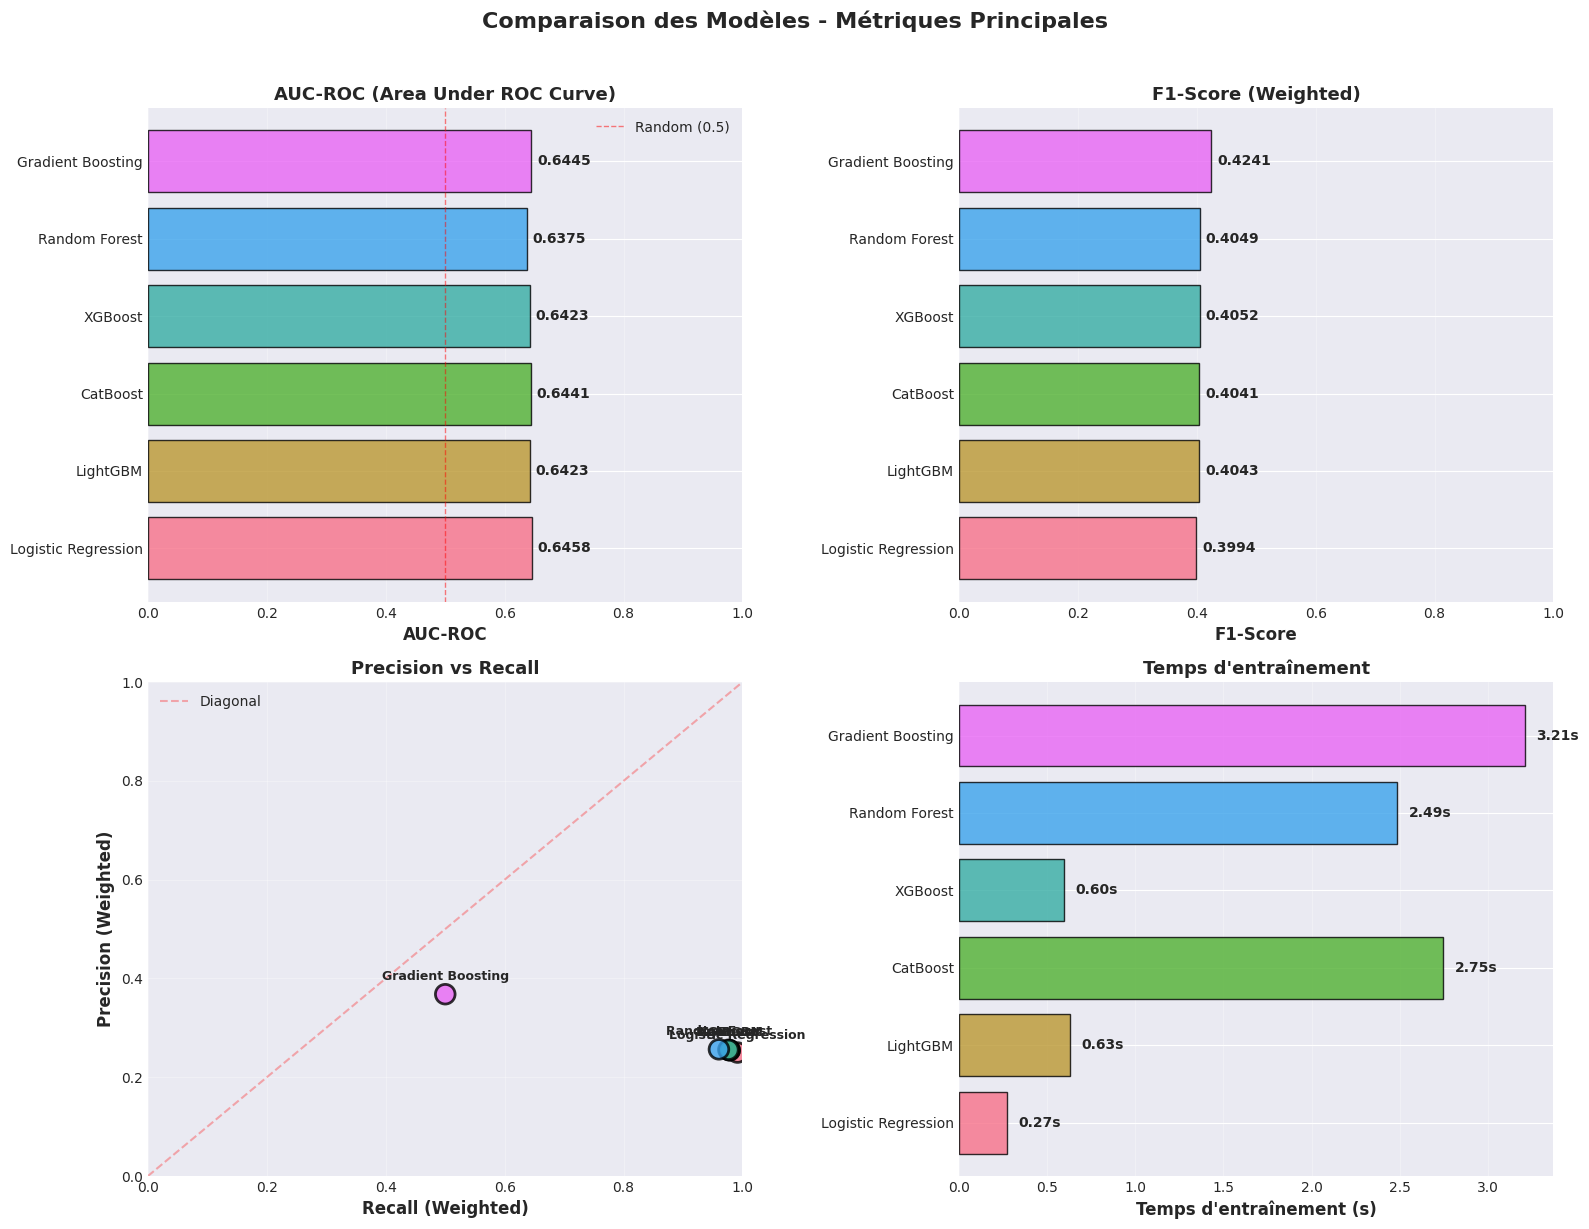

Visualisation générée avec succès


In [0]:
# ============================================================
# VISUALISATION : COMPARAISON DES MÉTRIQUES PRINCIPALES
# ============================================================
print("\n" + "=" * 60)
print("VISUALISATION : COMPARAISON DES MODÈLES")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparaison des Modèles - Métriques Principales', fontsize=16, fontweight='bold', y=1.02)

colors = sns.color_palette("husl", len(comparison_df))

# 1. AUC-ROC
ax1 = axes[0, 0]
bars1 = ax1.barh(comparison_df['model'], comparison_df['auc_roc'], color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('AUC-ROC', fontsize=12, fontweight='bold')
ax1.set_title('AUC-ROC (Area Under ROC Curve)', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Random (0.5)')
for i, (bar, val) in enumerate(zip(bars1, comparison_df['auc_roc'])):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# 2. F1-Score (Weighted)
ax2 = axes[0, 1]
bars2 = ax2.barh(comparison_df['model'], comparison_df['f1'], color=colors, alpha=0.8, edgecolor='black')
ax2.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax2.set_title('F1-Score (Weighted)', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 1)
for i, (bar, val) in enumerate(zip(bars2, comparison_df['f1'])):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. Precision vs Recall
ax3 = axes[1, 0]
ax3.scatter(comparison_df['recall'], comparison_df['precision'], s=200, c=colors, alpha=0.8, edgecolor='black', linewidth=2)
for i, model in enumerate(comparison_df['model']):
    ax3.annotate(model, (comparison_df['recall'].iloc[i], comparison_df['precision'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')
ax3.set_xlabel('Recall (Weighted)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Precision (Weighted)', fontsize=12, fontweight='bold')
ax3.set_title('Precision vs Recall', fontsize=13, fontweight='bold')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.grid(alpha=0.3)
ax3.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='Diagonal')
ax3.legend()

# 4. Training Time
ax4 = axes[1, 1]
bars4 = ax4.barh(comparison_df['model'], comparison_df['training_time'], color=colors, alpha=0.8, edgecolor='black')
ax4.set_xlabel("Temps d'entraînement (s)", fontsize=12, fontweight='bold')
ax4.set_title("Temps d'entraînement", fontsize=13, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars4, comparison_df['training_time'])):
    ax4.text(val + max(comparison_df['training_time'])*0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}s', va='center', fontsize=10, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("Visualisation générée avec succès")



VISUALISATION : MÉTRIQUES CLASSE POSITIVE


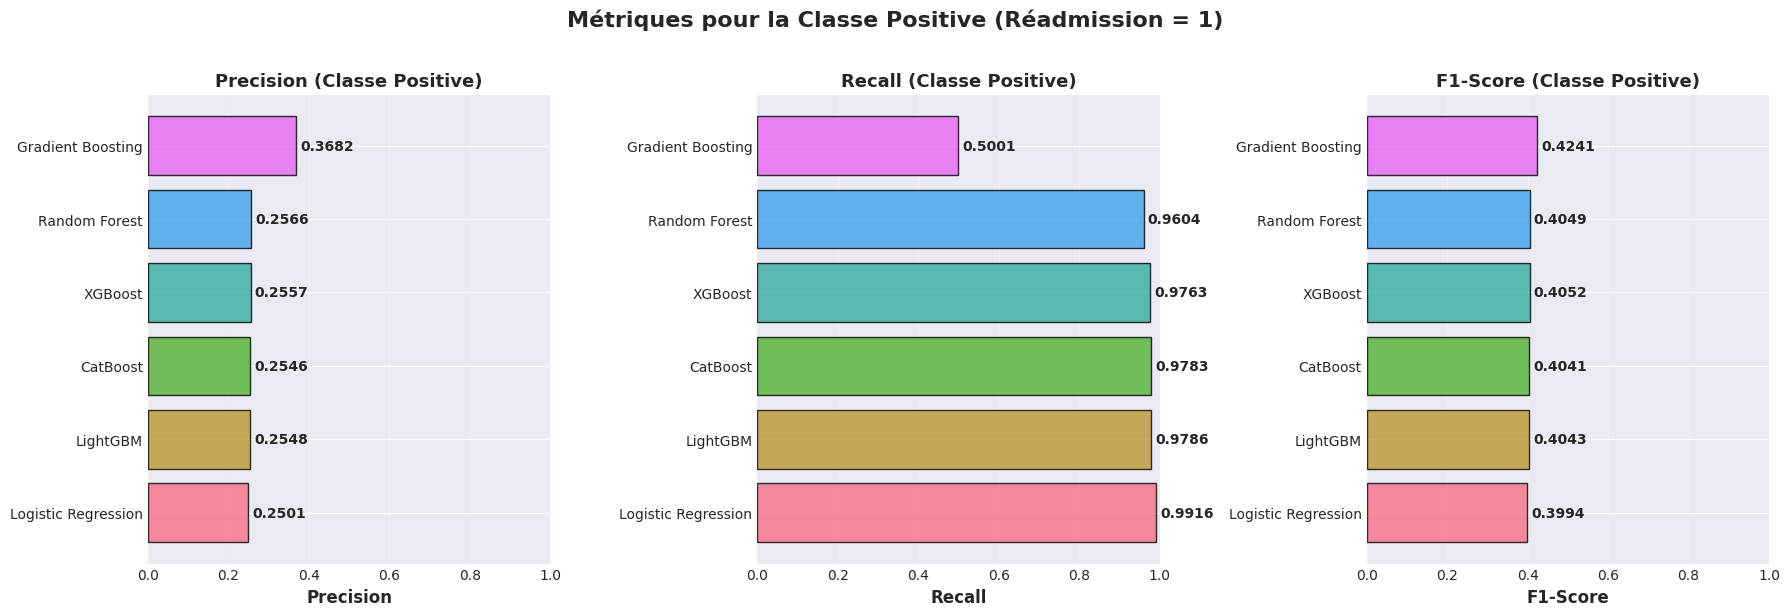

Visualisation générée avec succès


In [0]:
# ============================================================
# VISUALISATION : MÉTRIQUES CLASSE POSITIVE (Réadmission)
# ============================================================
print("\n" + "=" * 60)
print("VISUALISATION : MÉTRIQUES CLASSE POSITIVE")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Métriques pour la Classe Positive (Réadmission = 1)', fontsize=16, fontweight='bold', y=1.02)

colors = sns.color_palette("husl", len(comparison_df))

# 1. Precision Classe 1
ax1 = axes[0]
bars1 = ax1.barh(comparison_df['model'], comparison_df['precision_class1'], color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('Precision', fontsize=12, fontweight='bold')
ax1.set_title('Precision (Classe Positive)', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 1)
for i, (bar, val) in enumerate(zip(bars1, comparison_df['precision_class1'])):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Recall Classe 1
ax2 = axes[1]
bars2 = ax2.barh(comparison_df['model'], comparison_df['recall_class1'], color=colors, alpha=0.8, edgecolor='black')
ax2.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax2.set_title('Recall (Classe Positive)', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 1)
for i, (bar, val) in enumerate(zip(bars2, comparison_df['recall_class1'])):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. F1-Score Classe 1
ax3 = axes[2]
bars3 = ax3.barh(comparison_df['model'], comparison_df['f1_class1'], color=colors, alpha=0.8, edgecolor='black')
ax3.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax3.set_title('F1-Score (Classe Positive)', fontsize=13, fontweight='bold')
ax3.set_xlim(0, 1)
for i, (bar, val) in enumerate(zip(bars3, comparison_df['f1_class1'])):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("Visualisation générée avec succès")


INFO:py4j.clientserver:Received command c on object id p0



VISUALISATION : RADAR CHART


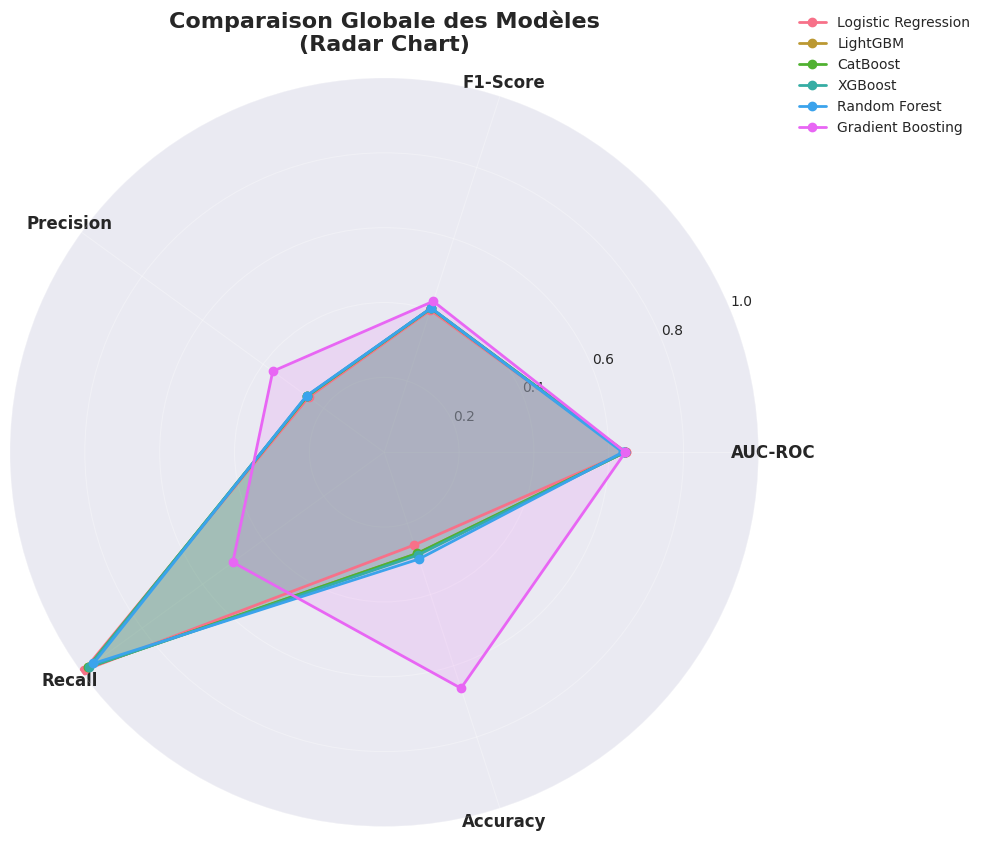

Radar chart généré avec succès


In [0]:
# ============================================================
# VISUALISATION : RADAR CHART - COMPARAISON GLOBALE
# ============================================================
print("\n" + "=" * 60)
print("VISUALISATION : RADAR CHART")
print("=" * 60)

metrics = ['auc_roc', 'f1', 'precision', 'recall', 'accuracy']
metric_labels = ['AUC-ROC', 'F1-Score', 'Precision', 'Recall', 'Accuracy']
num_vars = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
colors_radar = sns.color_palette("husl", len(comparison_df))

for idx, row in comparison_df.iterrows():
    values = [row[m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['model'], color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, size=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=10)
ax.grid(True, alpha=0.3)

plt.title('Comparaison Globale des Modèles\n(Radar Chart)', size=16, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()
print("Radar chart généré avec succès")



VISUALISATION : HEATMAP


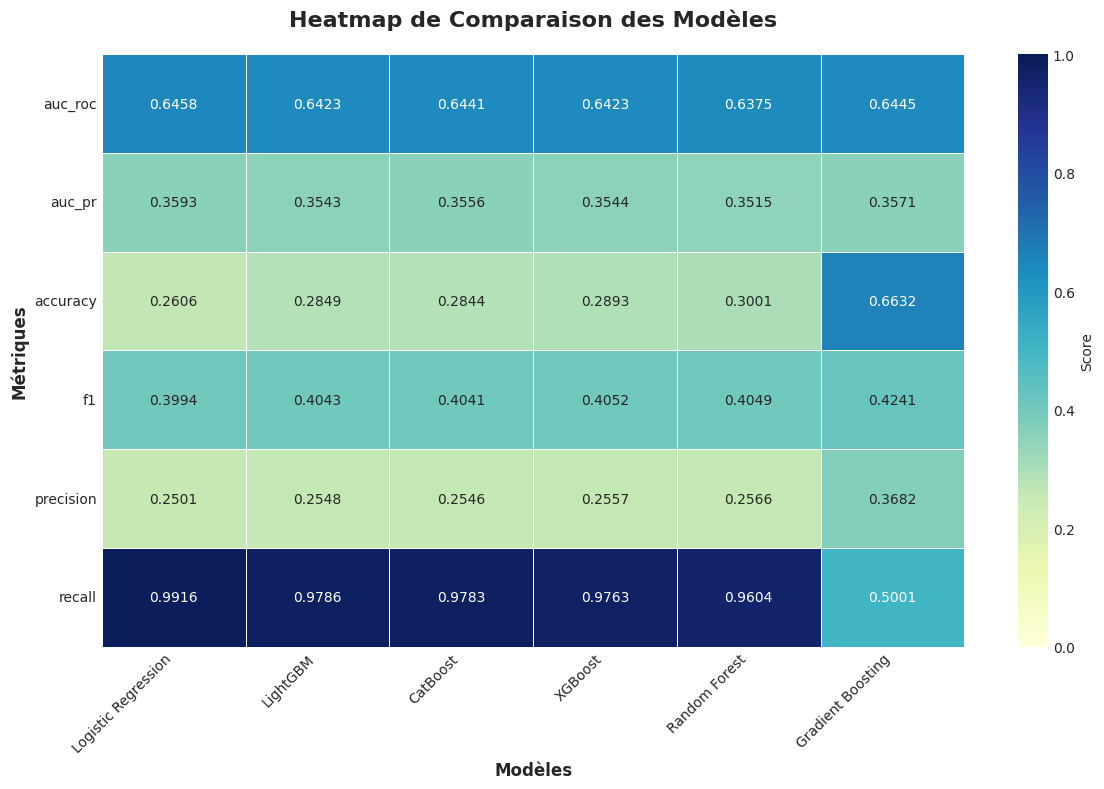

Heatmap générée avec succès


In [0]:
# ============================================================
# VISUALISATION : HEATMAP - MATRICE DE COMPARAISON
# ============================================================
print("\n" + "=" * 60)
print("VISUALISATION : HEATMAP")
print("=" * 60)

heatmap_data = comparison_df.set_index('model')[['auc_roc', 'auc_pr', 'accuracy', 'f1', 'precision', 'recall']]
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data.T, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'Score'}, vmin=0, vmax=1)
plt.title('Heatmap de Comparaison des Modèles', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Modèles', fontsize=12, fontweight='bold')
plt.ylabel('Métriques', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("Heatmap générée avec succès")


In [0]:
# ============================================================
# SÉLECTION DU MEILLEUR MODÈLE
# ============================================================
print("\n" + "=" * 60)
print("SÉLECTION DU MEILLEUR MODÈLE")
print("=" * 60)
model_mapping = {
    "Logistic Regression": pipeline_lr,
    "Random Forest": pipeline_rf,
    "Gradient Boosting": pipeline_gbc,
    "XGBoost": pipeline_xgb,
    "LightGBM": pipeline_lgbm,
    "CatBoost": pipeline_catboost
} # Critère clinique : Recall classe positive ≥ 0.95 
best_models = comparison_df[comparison_df['recall_class1'] >= 0.95]
if not best_models.empty:
    best_model_name = best_models.iloc[0]['model']
else:
    best_model_name = comparison_df.iloc[0]['model']
best_model_pipeline = model_mapping[best_model_name]
best_auc_roc = comparison_df.loc[comparison_df['model'] == best_model_name, 'auc_roc'].values[0]
print(f"\nMEILLEUR MODÈLE SÉLECTIONNÉ : {best_model_name}")
print(f"   AUC-ROC : {best_auc_roc:.4f}")
print(f"   Prêt pour l'évaluation finale et le déploiement")


SÉLECTION DU MEILLEUR MODÈLE

MEILLEUR MODÈLE SÉLECTIONNÉ : Logistic Regression
   AUC-ROC : 0.6458
   Prêt pour l'évaluation finale et le déploiement


In [0]:
# ============================================================
# SAUVEGARDE DU MEILLEUR MODÈLE
# ============================================================
print("\n" + "=" * 60)
print("SAUVEGARDE DU MEILLEUR MODÈLE")
print("=" * 60)

import joblib
import os
import mlflow
import mlflow.sklearn

# Chemin de sauvegarde local
model_dir = "./saved_models/"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "best_hospital_readmission_model.pkl")

print(f"\nSAUVEGARDE DU MODÈLE LOCAL...")
try:
    joblib.dump(best_model_pipeline, model_path)
    print(f" Modèle sauvegardé avec succès : {model_path}")
    file_size = os.path.getsize(model_path) / (1024 * 1024)
    print(f" Taille du fichier : {file_size:.2f} MB")
except Exception as e:
    print(f"Erreur lors de la sauvegarde : {e}")

# Sauvegarde dans MLflow
print(f"\nSAUVEGARDE DANS MLflow...")
with mlflow.start_run(run_name=f"Best_Model_{best_model_name}"):
    mlflow.sklearn.log_model(best_model_pipeline, "model")
    best_metrics = comparison_df[comparison_df['model'] == best_model_name].iloc[0]
    for metric in ['auc_roc','auc_pr','accuracy','f1','precision','recall','training_time']:
        mlflow.log_metric(metric, best_metrics[metric])
    mlflow.log_param("model_type", best_model_name)
    mlflow.log_param("n_features", len(feature_cols))
    mlflow.log_param("n_train_samples", len(X_train))
    print(f" Modèle enregistré dans MLflow avec succès")
print(f"\nProcessus de sauvegarde terminé")



SAUVEGARDE DU MEILLEUR MODÈLE

SAUVEGARDE DU MODÈLE LOCAL...
 Modèle sauvegardé avec succès : ./saved_models/best_hospital_readmission_model.pkl
 Taille du fichier : 0.01 MB

SAUVEGARDE DANS MLflow...


2026/01/09 13:02:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

 Modèle enregistré dans MLflow avec succès

Processus de sauvegarde terminé


In [0]:
# ============================================================
# ÉVALUATION FINALE SUR LE TEST SET
# ============================================================
print("\n" + "=" * 60)
print(f"ÉVALUATION FINALE SUR LE TEST SET - {best_model_name}")
print("=" * 60)

print(f"Nombre d'observations : {len(X_test):,}")

# Prédictions
y_test_pred = best_model_pipeline.predict(X_test)
y_test_pred_proba = best_model_pipeline.predict_proba(X_test)[:, 1]

# Évaluation
test_results = evaluate_model_clinical(y_test, y_test_pred, y_test_pred_proba, f"{best_model_name} (TEST SET)")

print("\n" + "=" * 80)
print("RÉSULTATS FINAUX SUR TEST SET")
print("=" * 80)
for metric in ['auc_roc','auc_pr','accuracy','precision','recall','f1']:
    print(f"  - {metric.replace('_',' ').title():<12}: {test_results[metric]:.4f}")
print("=" * 80)


INFO:py4j.clientserver:Received command c on object id p0



ÉVALUATION FINALE SUR LE TEST SET - Logistic Regression
Nombre d'observations : 13,950

LOGISTIC REGRESSION (TEST SET) — seuil = [0.40540357 0.33284463 0.44059413 ... 0.69512885 0.59566083 0.38785384]
------------------------------------------------------------
 Recall (classe 1)     : 0.5655
 Precision (classe 1)  : 0.3479
 F1 (classe 1)         : 0.4308
 AUC-PR                : 0.3045
 AUC-ROC               : 0.6080

 MATRICE DE CONFUSION :
               Prédit 0     Prédit 1
 Réel 0 (TN/FP)      6825        3666
 Réel 1 (FN/TP)      1503        1956

 ERREURS CLINIQUES :
 FN (critiques)        : 1503
 FP (acceptables)      : 3666
------------------------------------------------------------

RÉSULTATS FINAUX SUR TEST SET
  - Auc Roc     : 0.6080
  - Auc Pr      : 0.3045
  - Accuracy    : 0.6295
  - Precision   : 0.3479
  - Recall      : 0.5655
  - F1          : 0.4308


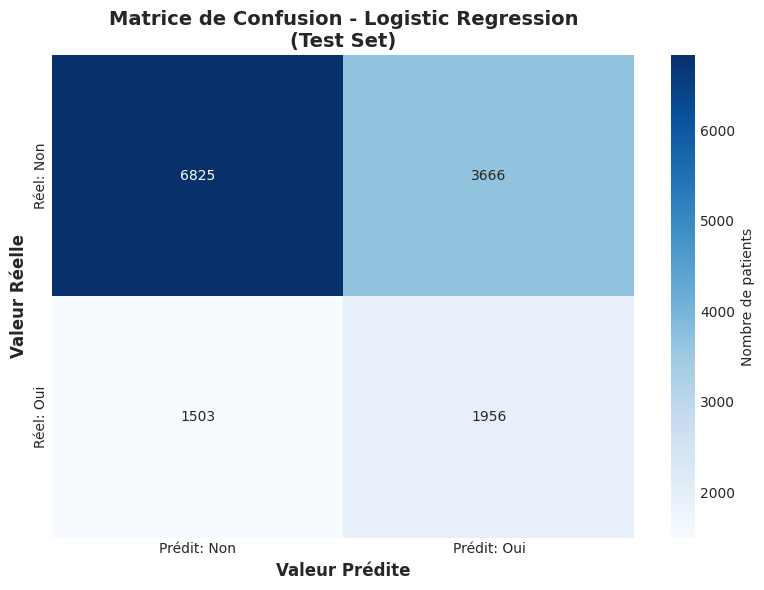

Visualisation générée avec succès


In [0]:
# ============================================================
# VISUALISATION : MATRICE DE CONFUSION (TEST SET)
# ============================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Non','Prédit: Oui'],
            yticklabels=['Réel: Non','Réel: Oui'],
            cbar_kws={'label':'Nombre de patients'})
plt.title(f'Matrice de Confusion - {best_model_name}\n(Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('Valeur Réelle', fontsize=12, fontweight='bold')
plt.xlabel('Valeur Prédite', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Visualisation générée avec succès")


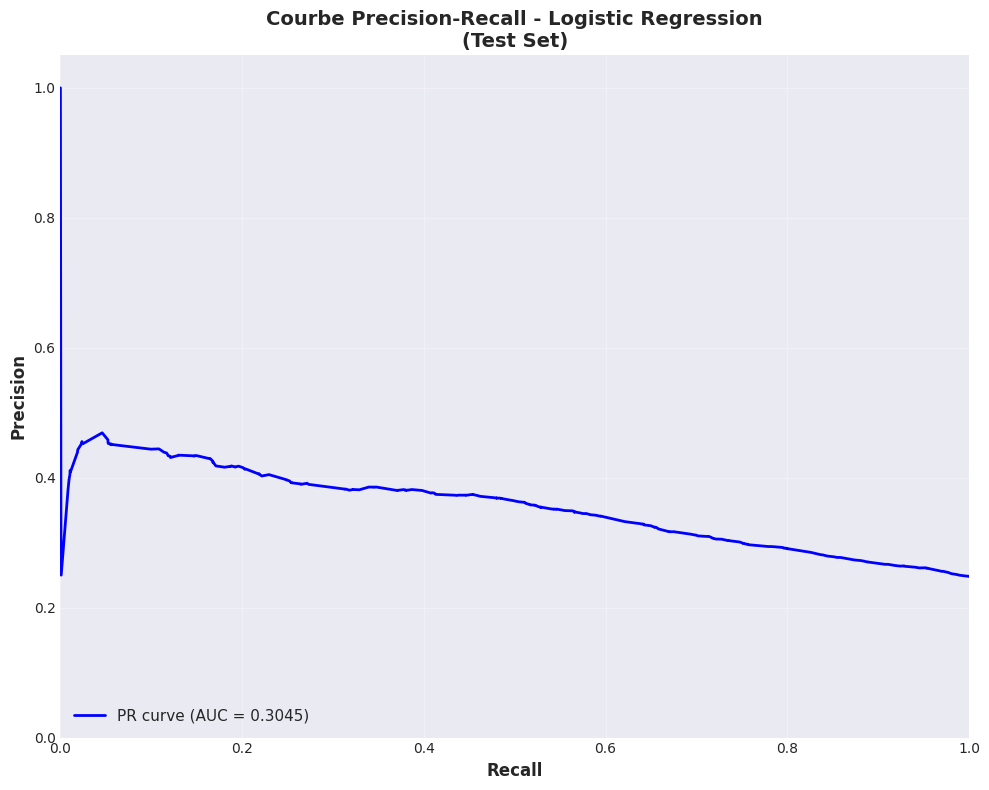

Courbe Precision-Recall générée avec succès


In [0]:
# ============================================================
# COURBE PRECISION-RECALL (TEST SET)
# ============================================================
from sklearn.metrics import precision_recall_curve
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(10,8))
plt.plot(recall_curve, precision_curve, color='blue', lw=2,
         label=f'PR curve (AUC = {test_results["auc_pr"]:.4f})')
plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title(f'Courbe Precision-Recall - {best_model_name}\n(Test Set)', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()
print("Courbe Precision-Recall générée avec succès")


In [0]:
# ============================================================
# FEATURE IMPORTANCE (si disponible)
# ============================================================
print("\n" + "=" * 60)
print("ANALYSE : FEATURE IMPORTANCE")
print("=" * 60)
try:
    classifier = best_model_pipeline.named_steps['classifier']
    if hasattr(classifier, 'feature_importances_'):
        preprocessor_fitted = best_model_pipeline.named_steps['preprocessor']
        cat_features = []
        if len(categorical_cols) > 0:
            cat_encoder = preprocessor_fitted.named_transformers_['cat']
            cat_features = cat_encoder.get_feature_names_out(categorical_cols).tolist()
        feature_names = cat_features + numerical_cols
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': classifier.feature_importances_
        }).sort_values('importance', ascending=False).head(20)
        
        print("\nTOP 20 FEATURES LES PLUS IMPORTANTES :")
        print(importance_df.to_string(index=False))
        
        plt.figure(figsize=(12,8))
        plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue', edgecolor='black')
        plt.xlabel('Importance', fontsize=12, fontweight='bold')
        plt.ylabel('Features', fontsize=12, fontweight='bold')
        plt.title(f'Top 20 Features Importance - {best_model_name}', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        print("Feature importance analysée avec succès")
    else:
        print(f"Le modèle {best_model_name} ne supporte pas feature_importances_")
except Exception as e:
    print(f"Erreur lors de l'analyse de feature importance : {e}")


INFO:py4j.clientserver:Received command c on object id p0



ANALYSE : FEATURE IMPORTANCE
Le modèle Logistic Regression ne supporte pas feature_importances_



COMPARAISON VALIDATION vs TEST

TABLEAU COMPARATIF :
 Métrique  Validation     Test  Différence  Différence (%)
  AUC-ROC    0.645800 0.608019   -0.037781           -5.85
   AUC-PR    0.359264 0.304484   -0.054780          -15.25
 Accuracy    0.260573 0.629462    0.368889          141.57
 F1-Score    0.399418 0.430790    0.031372            7.85
Precision    0.250073 0.347919    0.097846           39.13
   Recall    0.991616 0.565481   -0.426135          -42.97


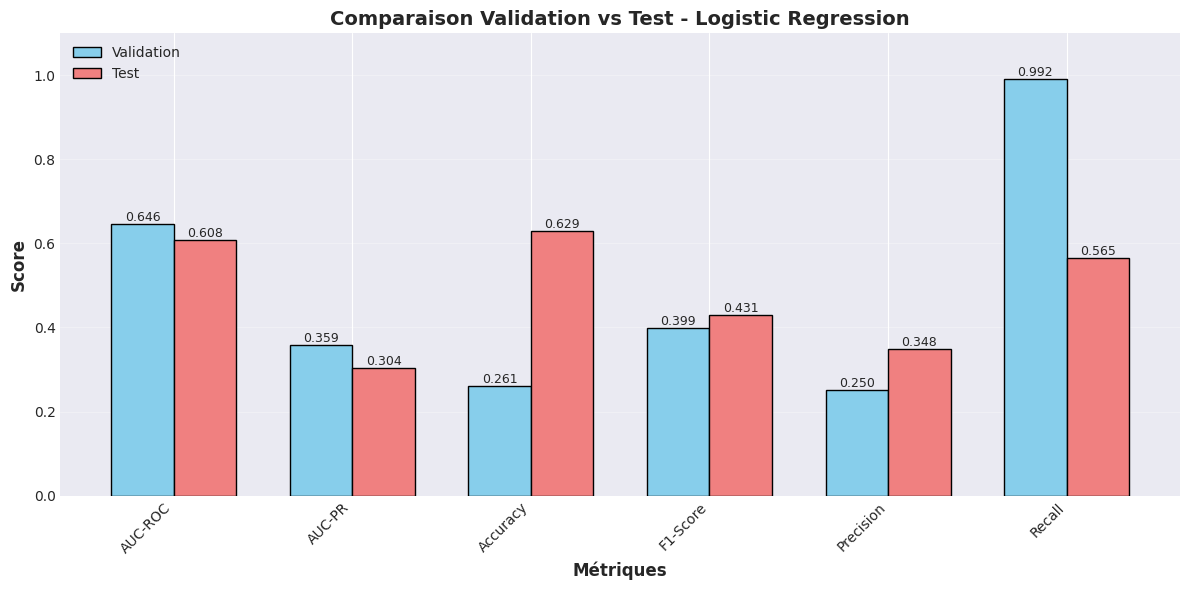

Comparaison générée avec succès


In [0]:
# ============================================================
# COMPARAISON VALIDATION vs TEST
# ============================================================
print("\n" + "=" * 60)
print("COMPARAISON VALIDATION vs TEST")
print("=" * 60)

val_metrics = comparison_df[comparison_df['model'] == best_model_name].iloc[0]

comparison_val_test = pd.DataFrame({
    'Métrique': ['AUC-ROC', 'AUC-PR', 'Accuracy', 'F1-Score', 'Precision', 'Recall'],
    'Validation': [val_metrics[m] for m in ['auc_roc','auc_pr','accuracy','f1','precision','recall']],
    'Test': [test_results[m] for m in ['auc_roc','auc_pr','accuracy','f1','precision','recall']]
})

comparison_val_test['Différence'] = comparison_val_test['Test'] - comparison_val_test['Validation']
comparison_val_test['Différence (%)'] = (comparison_val_test['Différence'] / comparison_val_test['Validation'] * 100).round(2)

print("\nTABLEAU COMPARATIF :")
print(comparison_val_test.to_string(index=False))

fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(comparison_val_test))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_val_test['Validation'], width, label='Validation', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_val_test['Test'], width, label='Test', color='lightcoral', edgecolor='black')

ax.set_xlabel('Métriques', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'Comparaison Validation vs Test - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_val_test['Métrique'], rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print("Comparaison générée avec succès")


In [0]:
# ============================================================
# RAPPORT DE CLASSIFICATION DÉTAILLÉ (TEST SET)
# ============================================================
print("\n" + "=" * 60)
print("RAPPORT DE CLASSIFICATION DÉTAILLÉ (TEST SET)")
print("=" * 60)

from sklearn.metrics import classification_report

# Génération du rapport
report = classification_report(y_test, y_test_pred, target_names=['Non Réadmis', 'Réadmis'])
print("\nRAPPORT COMPLET :")
print(report)

# Rapport sous forme de DataFrame pour meilleure visualisation
report_dict = classification_report(y_test, y_test_pred, target_names=['Non Réadmis', 'Réadmis'], output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
print("\nRAPPORT SOUS FORME TABULAIRE :")
print(report_df.to_string())


INFO:py4j.clientserver:Received command c on object id p0



RAPPORT DE CLASSIFICATION DÉTAILLÉ (TEST SET)

RAPPORT COMPLET :
              precision    recall  f1-score   support

 Non Réadmis       0.82      0.65      0.73     10491
     Réadmis       0.35      0.57      0.43      3459

    accuracy                           0.63     13950
   macro avg       0.58      0.61      0.58     13950
weighted avg       0.70      0.63      0.65     13950


RAPPORT SOUS FORME TABULAIRE :
              precision    recall  f1-score       support
Non Réadmis    0.819524  0.650558  0.725331  10491.000000
Réadmis        0.347919  0.565481  0.430790   3459.000000
accuracy       0.629462  0.629462  0.629462      0.629462
macro avg      0.583722  0.608019  0.578060  13950.000000
weighted avg   0.702587  0.629462  0.652297  13950.000000


In [0]:
# ============================================================
# RÉSUMÉ FINAL ET RECOMMANDATIONS
# ============================================================
print("\n" + "=" * 80)
print(" " * 20 + "RÉSUMÉ FINAL DU PROJET")
print("=" * 80)

# Informations sur le dataset
print(f"\nDATASET :")
print(f"Total observations : {len(df):,}")
print(f"Train : {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation : {len(X_val):,} ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test : {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)")
print(f"Features : {len(feature_cols)}")
print(f"Taux de réadmission : {(positives/total)*100:.2f}%")

# Modèles entraînés
print(f"\n🤖 MODÈLES ENTRAÎNÉS : {len(all_results)}")
for i, result in enumerate(all_results, 1):
    print(f"  {i}. {result['model']}")

# Meilleur modèle
print(f"\nMEILLEUR MODÈLE : {best_model_name}")
print(f" AUC-ROC (Validation) : {val_metrics['auc_roc']:.4f}")
print(f" AUC-ROC (Test)       : {test_results['auc_roc']:.4f}")
print(f" F1-Score (Test)      : {test_results['f1']:.4f}")
print(f" Precision (Test)     : {test_results['precision']:.4f}")
print(f" Recall (Test)        : {test_results['recall']:.4f}")

# Recommandations
print(f"\nRECOMMANDATIONS :")
print(f"1. Le modèle {best_model_name} est recommandé pour la production")
print(f"2. L'AUC-ROC de {test_results['auc_roc']:.4f} indique une bonne capacité de discrimination")
print(f"3. Considérer un tuning des hyperparamètres pour améliorer les performances")
print(f"4. Surveiller les performances en production (monitoring)")
print(f"5. Réévaluer périodiquement avec de nouvelles données")

# Livrables créés
print(f"\nLIVRABLES CRÉÉS :")
print(f"- Modèle baseline : Logistic Regression")
print(f"- 5 modèles avancés entraînés et évalués")
print(f"- Tableau comparatif : workspace.default.models_comparison")
print(f"- Meilleur modèle sauvegardé : {model_path}")
print(f"- Modèle enregistré dans MLflow")
print(f"- Visualisations et métriques complètes")
print("\n" + "=" * 80)
print(" " * 25 + "NOTEBOOK TERMINÉ")



                    RÉSUMÉ FINAL DU PROJET

DATASET :
Total observations : 69,750
Train : 41,850 (60.0%)
Validation : 13,950 (20.0%)
Test : 13,950 (20.0%)
Features : 7
Taux de réadmission : 24.79%

🤖 MODÈLES ENTRAÎNÉS : 6
  1. Logistic Regression
  2. Random Forest
  3. Gradient Boosting
  4. XGBoost
  5. LightGBM
  6. CatBoost

MEILLEUR MODÈLE : Logistic Regression
 AUC-ROC (Validation) : 0.6458
 AUC-ROC (Test)       : 0.6080
 F1-Score (Test)      : 0.4308
 Precision (Test)     : 0.3479
 Recall (Test)        : 0.5655

RECOMMANDATIONS :
1. Le modèle Logistic Regression est recommandé pour la production
2. L'AUC-ROC de 0.6080 indique une bonne capacité de discrimination
3. Considérer un tuning des hyperparamètres pour améliorer les performances
4. Surveiller les performances en production (monitoring)
5. Réévaluer périodiquement avec de nouvelles données

LIVRABLES CRÉÉS :
- Modèle baseline : Logistic Regression
- 5 modèles avancés entraînés et évalués
- Tableau comparatif : workspace.